In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## Merged data

Read files

In [3]:
data = Path("../data/processed/netflix.csv")
df = pd.read_csv(data)

In [4]:
df

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458333,458333,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN
458334,458334,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1,NaN,NaN,NaN,NaN,NaN,NaN
458335,458335,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1,TV (English),2.0,62150000.0,NaN,NaN,1.0
458336,458336,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1,TV (Non-English),10.0,9140000.0,NaN,NaN,1.0


In [5]:
# Overview
df.describe()

,Unnamed: 0,country_weekly_rank,country_cumulative_weeks_in_top_10,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
count,458338.000000,458338.000000,458338.000000,306075.000000,3.060750e+05,180673.000000,1.806730e+05,306075.000000
mean,229168.500000,5.499784,3.441938,3.688325,3.181426e+07,243.081659,8.229346e+06,3.080189
std,132310.928177,2.872254,6.056793,2.546472,3.855473e+07,183.437471,8.069365e+06,3.575171
min,0.000000,1.000000,1.000000,1.000000,8.000000e+05,0.000000,7.000000e+05,1.000000
25%,114584.250000,3.000000,1.000000,2.000000,1.155000e+07,105.000000,3.300000e+06,1.000000
50%,229168.500000,5.000000,2.000000,3.000000,2.090000e+07,160.002000,5.500000e+06,2.000000
75%,343752.750000,8.000000,3.000000,5.000000,3.805000e+07,354.000000,9.900000e+06,3.000000
max,458337.000000,10.000000,127.000000,10.000000,5.717600e+08,2854.998000,6.800000e+07,39.000000


In [6]:
# Check total null values by column
df.isna().sum()

Unnamed: 0                                 0
country_name                               0
country_iso2                               0
week                                       0
country_category                           0
country_weekly_rank                        0
show_title                                 0
season_title                          234434
country_cumulative_weeks_in_top_10         0
global_category                       152263
global_weekly_rank                    152263
global_weekly_hours_viewed            152263
runtime                               277665
global_weekly_views                   277665
global_cumulative_weeks_in_top_10     152263
dtype: int64

Seaborn pairplot for overview

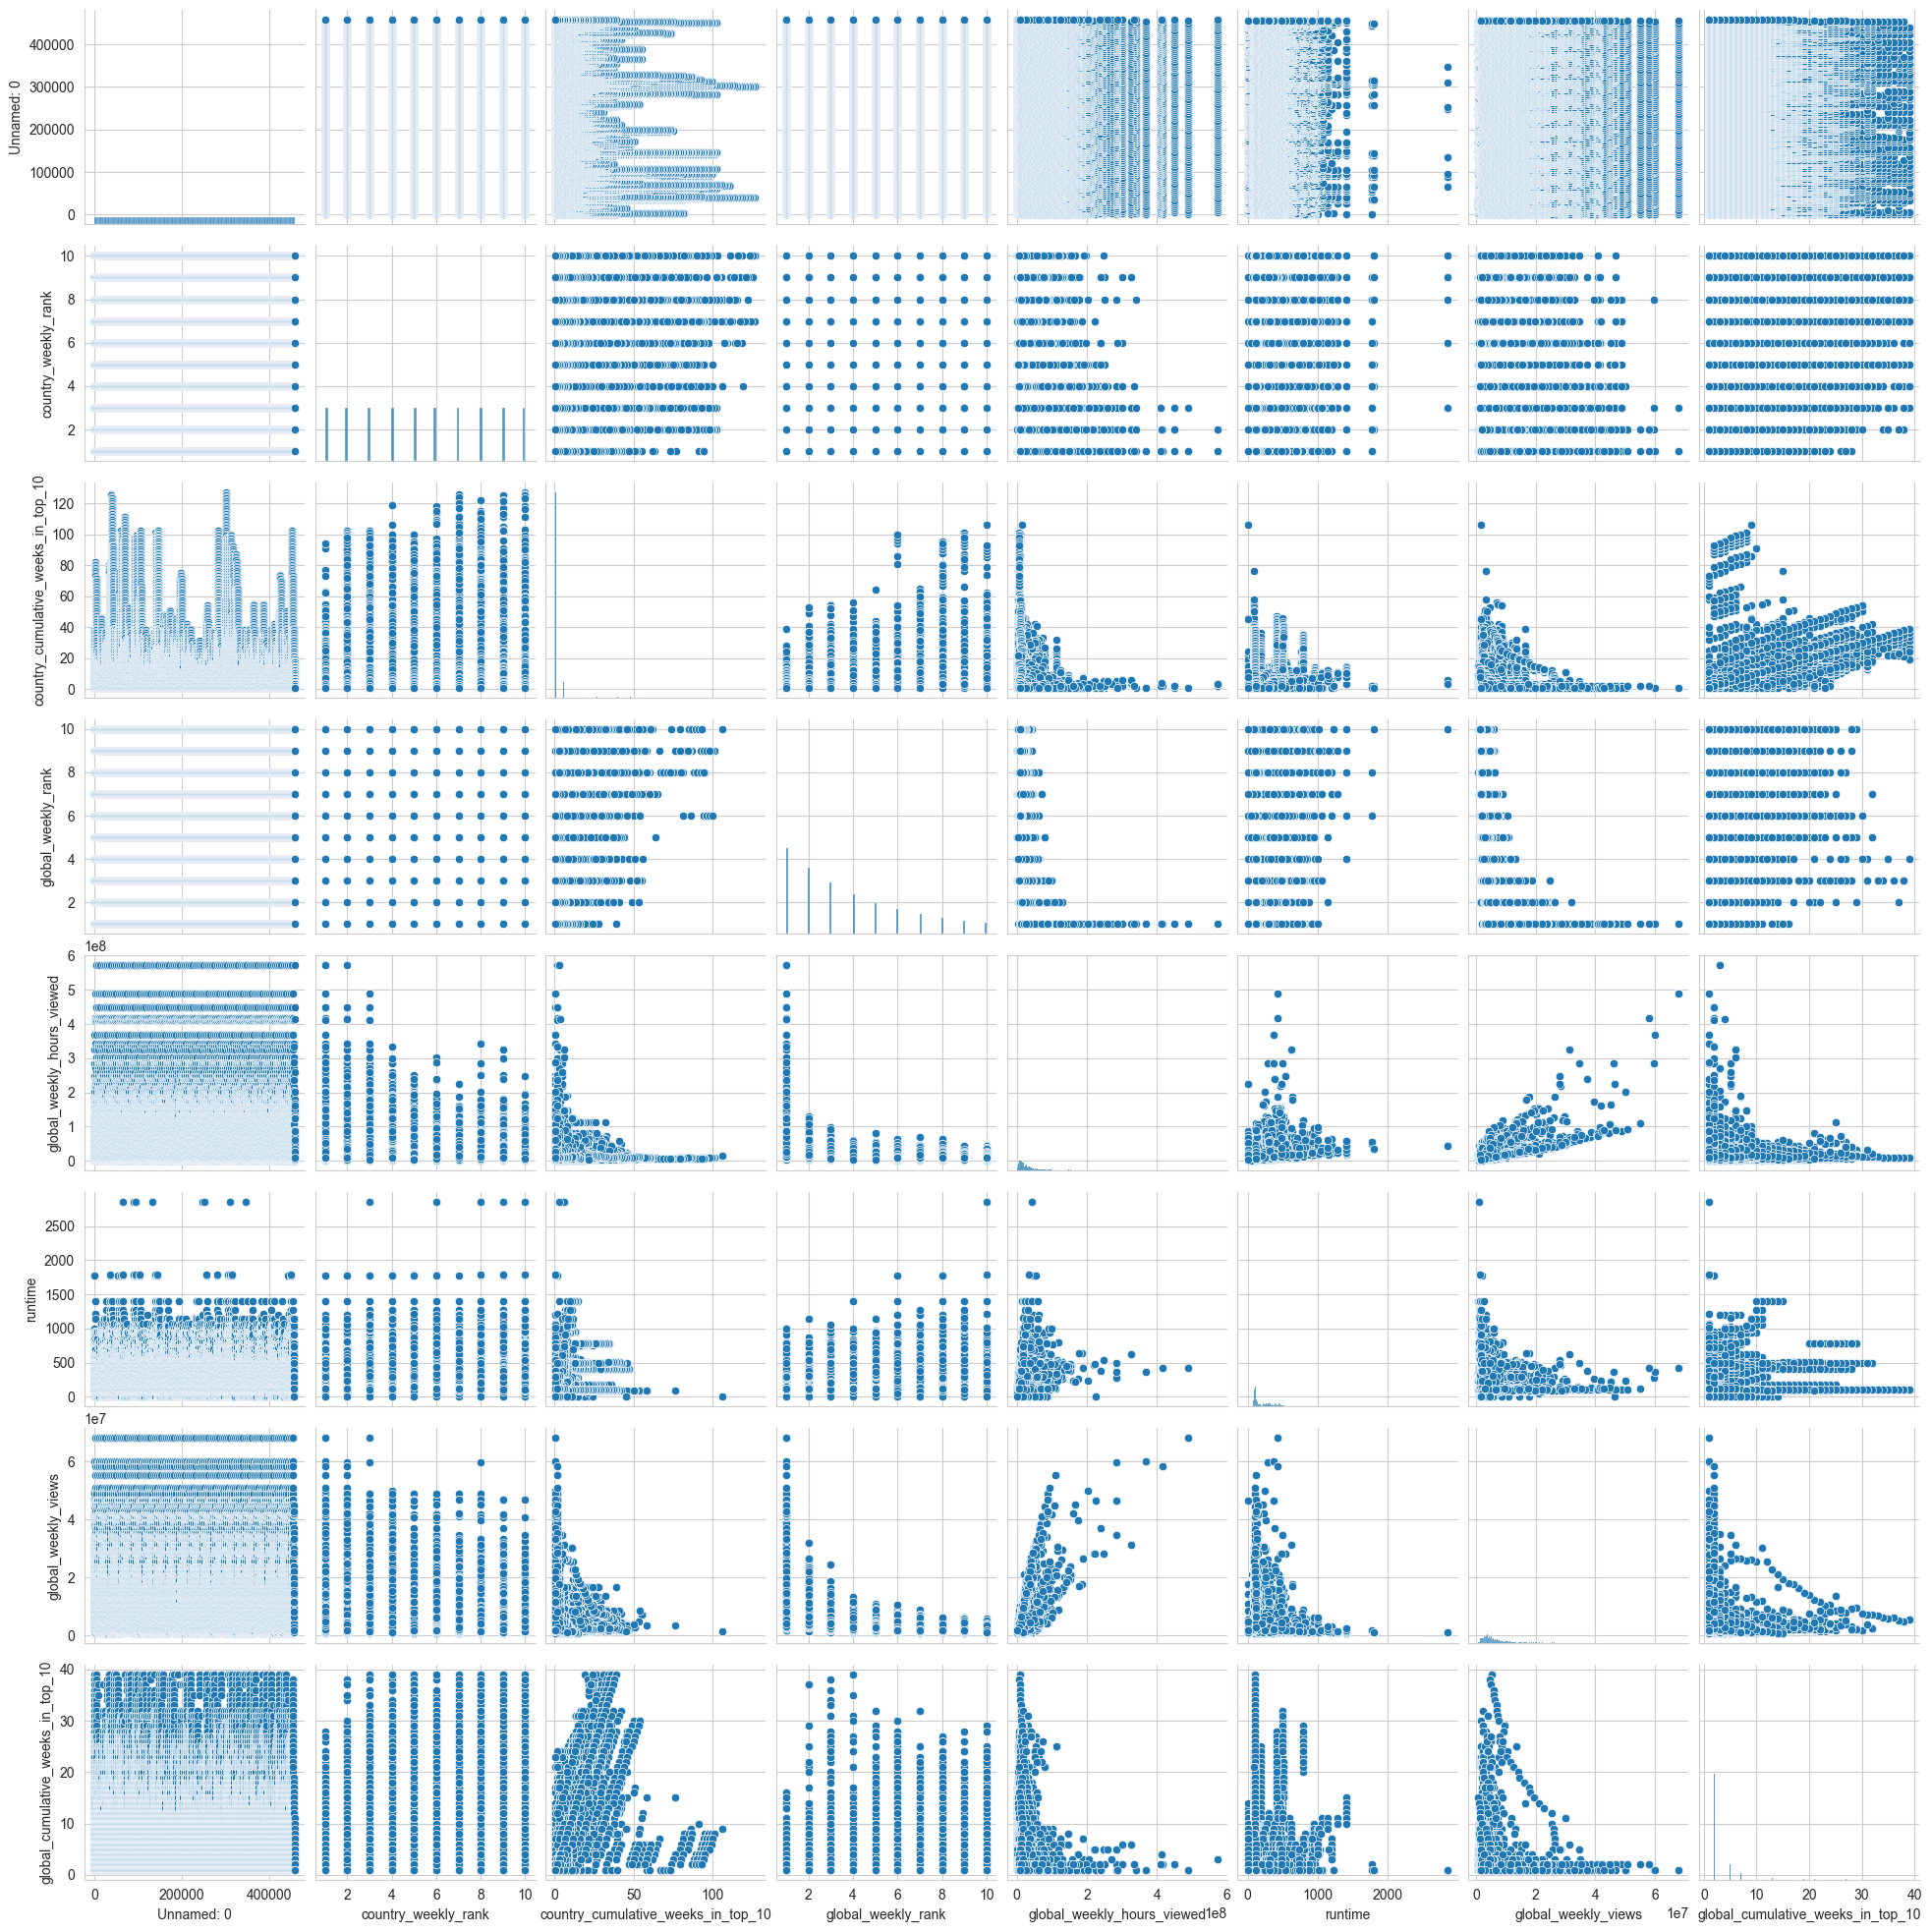

In [7]:
sns.pairplot(df)

Relationship of runtime and global weekly views

In [8]:
df_films_runtime = df.loc[(df.runtime < 240) & (df.country_category == "Films")]

Text(0, 0.5, 'Global weekly views')

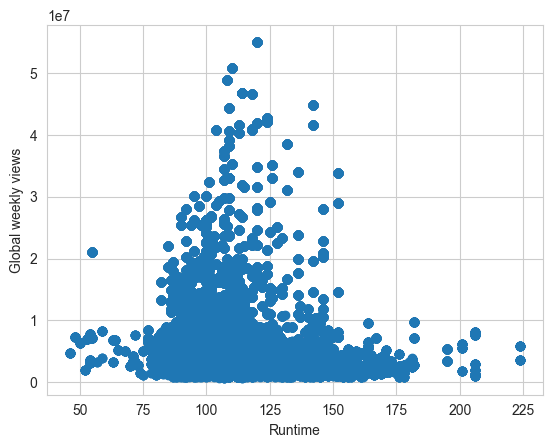

In [9]:
plt.scatter(x=df_films_runtime.runtime, y=df_films_runtime.global_weekly_views)
plt.xlabel('Runtime')
plt.ylabel('Global weekly views')

In [10]:
# What categories are there?
df.global_category.unique()

array(['Films (English)', 'Films (Non-English)', nan, 'TV (Non-English)',
       'TV (English)'], dtype=object)

In [11]:
df

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458333,458333,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN
458334,458334,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1,NaN,NaN,NaN,NaN,NaN,NaN
458335,458335,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1,TV (English),2.0,62150000.0,NaN,NaN,1.0
458336,458336,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1,TV (Non-English),10.0,9140000.0,NaN,NaN,1.0


In [12]:
most_viewed_per_country_index = df.groupby('country_name')['global_weekly_hours_viewed'].idxmax()

In [13]:
df.loc[most_viewed_per_country_index]


,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
4652,4652,Argentina,AR,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
9572,9572,Australia,AU,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
14493,14493,Austria,AT,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
19415,19415,Bahamas,BS,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
24335,24335,Bahrain,BH,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438384,438384,United Kingdom,GB,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
443304,443304,United States,US,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
448226,448226,Uruguay,UY,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0
453148,453148,Venezuela,VE,2021-10-03,TV,1,Squid Game,Squid Game: Season 1,3,TV (Non-English),1.0,571760000.0,NaN,NaN,3.0


___

## Global All time

In [14]:
import warnings

In [15]:
# Ignore excel formatting warning
warnings.simplefilter("ignore")

In [16]:
global_alltime = pd.read_excel('../data/raw/global_alltime.xlsx')

In [17]:
global_alltime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   category                    40 non-null     object 
 1   rank                        40 non-null     int64  
 2   show_title                  40 non-null     object 
 3   season_title                20 non-null     object 
 4   hours_viewed_first_91_days  40 non-null     int64  
 5   runtime                     40 non-null     float64
 6   views_first_91_days         40 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.3+ KB


In [18]:
# Most viewed
global_alltime.sort_values('views_first_91_days', ascending=False)

,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,KPop Demon Hunters,NaN,541800000,1.6667,325100000
30,TV (Non-English),1,Squid Game,Squid Game: Season 1,2205200000,8.3167,265200000
20,TV (English),1,Wednesday,Wednesday: Season 1,1718800000,6.8167,252100000
1,Films (English),2,Red Notice,NaN,454200000,1.9667,230900000
31,TV (Non-English),2,Squid Game,Squid Game: Season 2,1380100000,7.1667,192600000
2,Films (English),3,Carry-On,NaN,344100000,2.0000,172100000
3,Films (English),4,Don't Look Up,NaN,408600000,2.3833,171400000
4,Films (English),5,The Adam Project,NaN,281000000,1.7833,157600000
5,Films (English),6,Bird Box,NaN,325300000,2.0667,157400000
6,Films (English),7,Back in Action,NaN,279700000,1.9000,147200000


In [19]:
# Most hours viewed
global_alltime.sort_values('hours_viewed_first_91_days', ascending=False)

,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
30,TV (Non-English),1,Squid Game,Squid Game: Season 1,2205200000,8.3167,265200000
22,TV (English),3,Stranger Things,Stranger Things 4,1838000000,13.0667,140700000
20,TV (English),1,Wednesday,Wednesday: Season 1,1718800000,6.8167,252100000
23,TV (English),4,Stranger Things,Stranger Things 5,1384500000,10.4000,133100000
31,TV (Non-English),2,Squid Game,Squid Game: Season 2,1380100000,7.1667,192600000
25,TV (English),6,DAHMER,DAHMER: Monster: The Jeffrey Dahmer Story,1031100000,8.9167,115600000
26,TV (English),7,Bridgerton,Bridgerton: Season 1,929300000,8.2000,113300000
24,TV (English),5,Wednesday,Wednesday: Season 2,928500000,7.7833,119300000
35,TV (Non-English),6,Money Heist,Money Heist: Part 5,900700000,9.0833,99200000
32,TV (Non-English),3,Squid Game,Squid Game: Season 3,894300000,6.1333,145800000


In [20]:
# Mean values of each category
global_alltime.groupby('category').mean()

,rank,hours_viewed_first_91_days,runtime,views_first_91_days
category,,,,
Films (English),5.5,3.526500e+08,2.01167,178240000.0
Films (Non-English),5.5,1.505900e+08,1.76500,84210000.0
TV (English),5.5,1.077280e+09,8.18000,133370000.0
TV (Non-English),5.5,7.873600e+08,6.14500,118540000.0


- People spend more time watching TV shows than films.
- English media more popular than non-english.

## Global Weekly

In [21]:
global_weekly = pd.read_excel('../data/raw/global_weekly.xlsx')

In [22]:
global_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9840 entries, 0 to 9839
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   week                        9840 non-null   object 
 1   category                    9840 non-null   object 
 2   weekly_rank                 9840 non-null   int64  
 3   show_title                  9840 non-null   object 
 4   season_title                4775 non-null   object 
 5   weekly_hours_viewed         9840 non-null   int64  
 6   runtime                     5760 non-null   float64
 7   weekly_views                5760 non-null   float64
 8   cumulative_weeks_in_top_10  9840 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 692.0+ KB


In [23]:
global_weekly.describe()

,weekly_rank,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
count,9840.000000,9.840000e+03,5760.000000,5.760000e+03,9840.000000
mean,5.500000,1.791958e+07,3.708078,4.802274e+06,3.254065
std,2.872427,2.579101e+07,3.159164,5.577252e+06,3.718918
min,1.000000,7.000000e+05,0.000000,6.000000e+05,1.000000
25%,3.000000,5.800000e+06,1.700000,1.900000e+06,1.000000
50%,5.500000,1.070500e+07,2.200000,3.100000e+06,2.000000
75%,8.000000,2.030000e+07,5.200000,5.300000e+06,4.000000
max,10.000000,5.717600e+08,47.583300,6.800000e+07,39.000000


In [35]:
global_weekly.isnull().sum() / len(global_weekly)

week                          0.000000
category                      0.000000
weekly_rank                   0.000000
show_title                    0.000000
season_title                  0.514736
weekly_hours_viewed           0.000000
runtime                       0.414634
weekly_views                  0.414634
cumulative_weeks_in_top_10    0.000000
dtype: float64

- 51% of season title is missing -> Films don't have season titles
- 41% of runtime is missing
- 41% of weekly views is missing


In [39]:
global_weekly.corr()

,weekly_rank,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
weekly_rank,1.000000,-0.460196,0.008786,-0.566208,0.137560
weekly_hours_viewed,-0.460196,1.000000,0.359013,0.703250,-0.011834
runtime,0.008786,0.359013,1.000000,-0.099097,0.148434
weekly_views,-0.566208,0.703250,-0.099097,1.000000,-0.077940
cumulative_weeks_in_top_10,0.137560,-0.011834,0.148434,-0.077940,1.000000


- Weekly hours viewed and weekly views strongly correlated
- Weekly views and weekly ranks negatively correlated (lower rank usually means less views)

## Country weekly

In [26]:
country_weekly = pd.read_excel('../data/raw/country_weekly.xlsx')

In [54]:
country_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458260 entries, 0 to 458259
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   country_name                458260 non-null  object
 1   country_iso2                458260 non-null  object
 2   week                        458260 non-null  object
 3   category                    458260 non-null  object
 4   weekly_rank                 458260 non-null  int64 
 5   show_title                  458260 non-null  object
 6   season_title                223904 non-null  object
 7   cumulative_weeks_in_top_10  458260 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 28.0+ MB


In [55]:
country_weekly.describe()

,weekly_rank,cumulative_weeks_in_top_10
count,458260.000000,458260.000000
mean,5.500000,3.442231
std,2.872284,6.057246
min,1.000000,1.000000
25%,3.000000,1.000000
50%,5.500000,2.000000
75%,8.000000,3.000000
max,10.000000,127.000000


In [71]:
country_weekly.groupby(["show_title", "category"])["cumulative_weeks_in_top_10"].max().sort_values(ascending=False)

show_title                              category
Money Heist                             TV          127
Lottie Dottie Chicken                   TV          126
Peppa Pig                               TV          111
Pablo Escobar, el patrón del mal        TV          102
Pasión de Gavilanes                     TV          102
                                                   ... 
The House Bunny                         Films         1
The House Next Door: Meet the Blacks 2  Films         1
The House of Flowers: The Movie         Films         1
The House of the Spirits                Films         1
Gandeevadhari Arjuna (Tamil)            Films         1
Name: cumulative_weeks_in_top_10, Length: 11169, dtype: int64

- Money Heist has the longest stay in top 10
- Mostly TV shows that have long stays and not films, due to TV shows running for a longer time